<a href="https://colab.research.google.com/github/InahH-004/Parking-Space-Detection/blob/Inah/Tahap_1_Persiapan_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!kaggle --version

Kaggle CLI 2.2.4


In [ ]:
# !pip install --upgrade kaggle

#Kredensial API Kaggle

In [ ]:
import os
from google.colab import userdata

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

kaggle_json_content = f'{{"username":"{userdata.get("Parkinglot")}","key":"{userdata.get("Parkinglot")}"}}'
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json_content)

!chmod 600 ~/.kaggle/kaggle.json

print("Kredensial Kaggle API telah dikonfigurasi.")


mkdir: cannot create directory ‘/root/.kaggle’: File exists
Kredensial Kaggle API telah dikonfigurasi.


#Import Dataset

In [ ]:
import os

DATASET_PATH = "./data"
if not os.path.exists(DATASET_PATH):
    !kaggle datasets download -d trainingdatapro/parking-space-detection-dataset --unzip -p {DATASET_PATH}
    print("Dataset berhasil diunduh dan diekstrak ke ./data")
else:
    print("Direktori data sudah tersedia.")

Dataset URL: https://www.kaggle.com/datasets/trainingdatapro/parking-space-detection-dataset
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 42.3M/42.3M [00:00<00:00, 64.1MB/s]

Dataset berhasil diunduh dan diekstrak ke ./data


##Configurasi

In [ ]:
CONFIG = {
    "IMG_SIZE": (64, 64),   #ukuran piksel tiap gambar di crop jadi 64x64 biar gk terlalu berat
    "XML_PATH": "./data/annotations.xml",
    "IMAGES_DIR": "./data/",
    "RANDOM_STATE": 42,
    "LABEL_MAP": {
        "free_parking_space": 0,                # Kosong
        "not_free_parking_space": 1,            # Terisi
        "partially_free_parking_space": 1       # Terisi
    }
}

##File Check

In [ ]:
import os
import xml.etree.ElementTree as ET

# Verifikasi keberadaan file utama
assert os.path.exists(CONFIG["XML_PATH"]), "File annotations.xml tidak ditemukan!"
assert os.path.exists(CONFIG["IMAGES_DIR"]), "Direktori citra tidak ditemukan!"

# Cek 1 sampel bounding box dari XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()
first_image_node = root.find('image')

print(f"Sample Image Name : {first_image_node.get('name')}")
# Mengubah dari 'box' menjadi 'polygon' untuk mencocokkan struktur XML
print(f"Jumlah Anotasi Polygon: {len(first_image_node.findall('polygon'))}")
print("Lingkungan siap digunakan untuk modul pengerjaan.")

Sample Image Name : images/0.png
Jumlah Anotasi Polygon: 28
Lingkungan siap digunakan untuk modul pengerjaan.


#Ekstrak ROI

In [ ]:
import os
import cv2
import xml.etree.ElementTree as ET
import numpy as np

# 1. Menyiapkan direktori penyimpanan berdasarkan label biner
PROCESSED_DIR = "./data/processed"
os.makedirs(os.path.join(PROCESSED_DIR, "0"), exist_ok=True)
os.makedirs(os.path.join(PROCESSED_DIR, "1"), exist_ok=True)

# 2. Membaca struktur file anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

print("Memulai ekstraksi ROI petak parkir...")
total_extracted = 0

# 3. Iterasi untuk memproses setiap gambar yang tercatat di XML
for image_node in root.findall('image'):
    img_name = image_node.get('name')
    img_path = os.path.join(CONFIG["IMAGES_DIR"], img_name)
    img = cv2.imread(img_path)

    # Lewati jika file gambar asli tidak ditemukan di direktori
    if img is None:
        # print(f"Peringatan: Gambar tidak ditemukan di {img_path}, melewati.")
        continue

    # 4. Iterasi setiap polygon (sebelumnya kotak batas) di dalam gambar
    for idx, polygon_node in enumerate(image_node.findall('polygon')):
        label = polygon_node.get('label')

        # Konversi label teks menjadi angka (0 atau 1) menggunakan kontrak data
        num_label = CONFIG["LABEL_MAP"].get(label, 1)

        # Ambil titik koordinat polygon dari atribut 'points'
        points_str = polygon_node.get('points')

        # Parsing string points ke list of tuples (x, y)
        points = []
        for pair in points_str.split(';') :
            x, y = map(float, pair.split(','))
            points.append((int(x), int(y)))

        # Ubah points menjadi array numpy untuk cv2.boundingRect
        points_np = np.array(points)

        # Hitung bounding box (xtl, ytl, width, height) yang mengelilingi polygon
        xtl, ytl, width, height = cv2.boundingRect(points_np)
        xbr, ybr = xtl + width, ytl + height

        # Cegah eror dengan memastikan koordinat tidak melampaui batas dimensi gambar asli
        img_height, img_width = img.shape[:2]
        ytl, ybr = max(0, ytl), min(img_height, ybr)
        xtl, xbr = max(0, xtl), min(img_width, xbr)

        # 5. Lakukan pemotongan (cropping) citra
        patch = img[ytl:ybr, xtl:xbr]

        # Abaikan jika hasil crop kosong (koordinat tidak valid atau terlalu kecil)
        if patch.size == 0 or patch.shape[0] < 5 or patch.shape[1] < 5: # Tambahkan validasi ukuran minimum
            # print(f"Peringatan: Patch kosong atau terlalu kecil untuk {img_name}, polygon {idx}, melewati.")
            continue

        # 6. Simpan potongan gambar (patch) ke direktori kelas yang sesuai
        # Membersihkan nama file jika img_name memiliki format folder seperti 'images/0.png'
        clean_name = img_name.replace("/", "_").replace("\\", "_").split('.')[0]
        patch_filename = f"{clean_name}_patch_{idx}.jpg"
        save_path = os.path.join(PROCESSED_DIR, str(num_label), patch_filename)

        cv2.imwrite(save_path, patch)
        total_extracted += 1

print(f"Proses selesai! Total {total_extracted} petak parkir berhasil diekstrak dan disimpan di {PROCESSED_DIR}.")

Memulai ekstraksi ROI petak parkir...
Proses selesai! Total 902 petak parkir berhasil diekstrak dan disimpan di ./data/processed.


In [ ]:
import xml.etree.ElementTree as ET

# Membaca struktur file anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

total_images_with_boxes = 0
total_boxes_found = 0 # Mengganti nama variabel menjadi total_polygons_found untuk kejelasan

# Iterasi setiap gambar yang tercatat di XML
for image_node in root.findall('image'):
    # Mengubah dari 'box' menjadi 'polygon' untuk mencocokkan struktur XML
    polygons = image_node.findall('polygon')
    if len(polygons) > 0:
        total_images_with_boxes += 1
        total_boxes_found += len(polygons)

print(f"Total gambar yang ditemukan dalam XML: {len(root.findall('image'))}")
print(f"Total gambar dengan setidaknya satu anotasi polygon: {total_images_with_boxes}")
print(f"Total anotasi polygon di seluruh gambar: {total_boxes_found}")


Total gambar yang ditemukan dalam XML: 30
Total gambar dengan setidaknya satu anotasi polygon: 30
Total anotasi polygon di seluruh gambar: 903


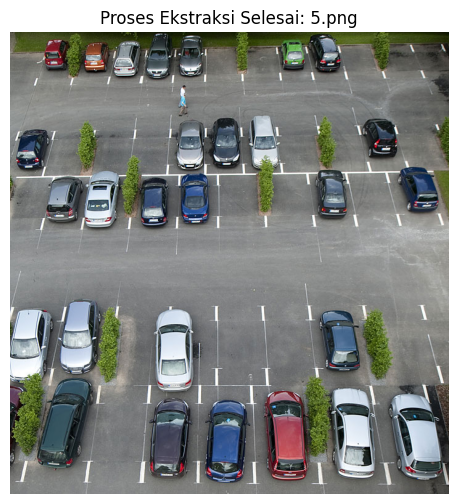

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt

# Mendefinisikan jalur file gambar
image_path = "./data/images/5.png"

# Memeriksa apakah file gambar tersedia
if os.path.exists(image_path):
    # Membaca gambar menggunakan OpenCV
    img = cv2.imread(image_path)

    # Mengonversi ruang warna dari BGR (bawaan OpenCV) ke RGB (bawaan Matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Menampilkan gambar
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Proses Ekstraksi Selesai: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()
else:
    print(f"File {image_path} tidak ditemukan di direktori saat ini.")

#Visualisasi Sementara

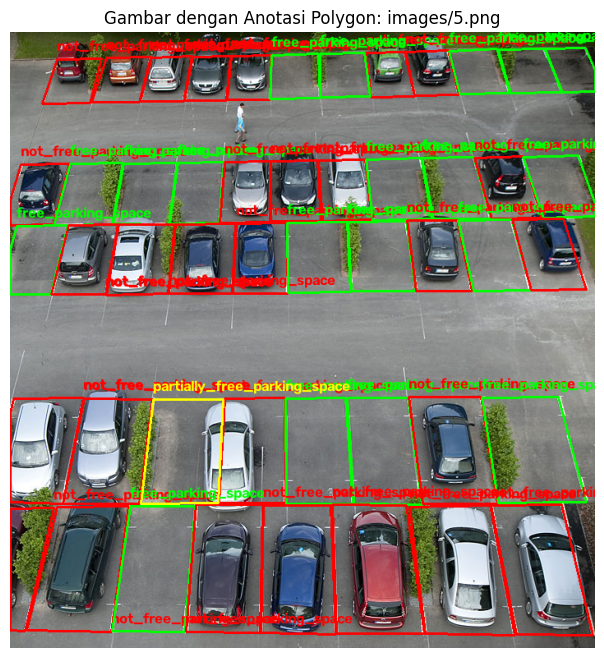

In [ ]:
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import numpy as np

# Pilih nama gambar untuk divisualisasikan
image_to_visualize = 'images/5.png' # Kita bisa pilih gambar pertama sebagai contoh

# Membaca gambar
image_path = os.path.join(CONFIG["IMAGES_DIR"], image_to_visualize)
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Membaca anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

# Cari node gambar yang sesuai
image_node = None
for node in root.findall('image'):
    if node.get('name') == image_to_visualize:
        image_node = node
        break

if image_node is not None:
    # Buat salinan gambar untuk digambar anotasi
    img_with_annotations = img_rgb.copy()

    # Iterasi setiap polygon di gambar ini
    for polygon_node in image_node.findall('polygon'):
        points_str = polygon_node.get('points')
        label = polygon_node.get('label')

        # Parsing string points ke list of tuples (x, y)
        points = []
        for pair in points_str.split(';') :
            x, y = map(float, pair.split(','))
            points.append([int(x), int(y)]) # Menggunakan list of lists untuk cv2.polylines

        # Ubah points menjadi array numpy
        points_np = np.array(points, np.int32)
        points_np = points_np.reshape((-1, 1, 2)) # Reshape untuk cv2.polylines

        # Tentukan warna berdasarkan label
        color = (0, 255, 0) # Hijau untuk 'free_parking_space'
        if 'not_free_parking_space' in label:
            color = (255, 0, 0) # Merah untuk 'not_free_parking_space'
        elif 'partially_free_parking_space' in label:
            color = (255, 255, 0) # Kuning untuk 'partially_free_parking_space'

        # Gambar polygon
        cv2.polylines(img_with_annotations, [points_np], isClosed=True, color=color, thickness=2)

        # Tambahkan teks label (opsional)
        # Cari titik tengah polygon atau gunakan salah satu titik sudut untuk teks
        if points_np.size > 0:
            text_x, text_y = points_np[0][0][0], points_np[0][0][1] - 10 # Sedikit di atas titik pertama
            cv2.putText(img_with_annotations, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Tampilkan gambar dengan anotasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_annotations)
    plt.title(f"Gambar dengan Anotasi Polygon: {image_to_visualize}")
    plt.axis('off')
    plt.show()
else:
    print(f"Node gambar untuk {image_to_visualize} tidak ditemukan dalam annotations.xml.")